In [25]:
## Importing the Python Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

In [26]:
# Download 5 years of AAPL daily data, explicitily requesting Adj close, as inital code ran without the adj close column
aapl = yf.download("AAPL", period="5y", interval="1d", auto_adjust=False)

# Flatten MultiIndex columns if yfinance returns them
if isinstance(aapl.columns, pd.MultiIndex):
    aapl.columns = aapl.columns.map(lambda x: x[0] if isinstance(x, tuple) else x)

# Reset index so Date becomes a normal column, as yf ran the date as year
aapl.reset_index(inplace=True)

# Display the first few rows to show the new column structure
display(aapl.head())

## Printing the shape of the Datframe
print(aapl.shape)


[*********************100%***********************]  1 of 1 completed


,Date,Adj Close,Close,High,Low,Open,Volume
0,2021-07-19,138.853394,142.449997,144.070007,141.669998,143.750000,121434600
1,2021-07-20,142.459991,146.149994,147.100006,142.960007,143.460007,96350000
2,2021-07-21,141.728943,145.399994,146.130005,144.630005,145.529999,74993500
3,2021-07-22,143.093582,146.800003,148.199997,145.809998,145.940002,77338200
4,2021-07-23,144.809158,148.559998,148.720001,146.919998,147.550003,71447400


(1255, 7)


## 1.  Data Transformation with Pandas

A. Data Cleaning

In [27]:
## Re-evaluating shape of the dataset (rows, columns)
aapl.shape

(1255, 7)

In [28]:
## Evaluating data types and non-null counts
aapl.info()

# Checking for duplicate rows
duplicate_count = aapl.duplicated().sum()
print("Total number of duplicate rows:", duplicate_count)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1255 entries, 0 to 1254
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       1255 non-null   datetime64[ns]
 1   Adj Close  1255 non-null   float64       
 2   Close      1255 non-null   float64       
 3   High       1255 non-null   float64       
 4   Low        1255 non-null   float64       
 5   Open       1255 non-null   float64       
 6   Volume     1255 non-null   int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 68.8 KB
Total number of duplicate rows: 0


B. Handling Missing Values

In [29]:
# Checking for missing values
aapl.isnull().sum()

,0
Date,0
Adj Close,0
Close,0
High,0
Low,0
Open,0
Volume,0


In [30]:
# Identifying Numerical Features
numerical_features = aapl.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Numerical Features:", numerical_features)

Numerical Features: ['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume']


In [31]:
##Identifying categorical Features
categorical_features = aapl.select_dtypes(include=['object']).columns.tolist()
print("Categorical Features:", categorical_features)

Categorical Features: []


In [32]:
##Identifying unique Identifiers
for col in aapl.columns:
    print(f"{col}: {aapl[col].nunique()} unique values out of {len(aapl)} rows")

Date: 1255 unique values out of 1255 rows
Adj Close: 1240 unique values out of 1255 rows
Close: 1193 unique values out of 1255 rows
High: 1197 unique values out of 1255 rows
Low: 1211 unique values out of 1255 rows
Open: 1190 unique values out of 1255 rows
Volume: 1254 unique values out of 1255 rows


## About the Dataset

This dataset tracks Apple Inc's (AAPL) daily stock market performance over
the past 5 years. Each row represents one trading day and captures how the
stock moved that day: the price it opened at, the highest and lowest points
it reached, the price it closed at, and the number of shares traded (Volume).
The Adjusted Close accounts for dividends and stock splits, giving a more
accurate picture of long-term price movement.

Comparing Open to Close on any given day shows whether AAPL gained or lost
value that day. Analyzing this data over 5 years makes it possible to observe
broader trends, seasonal patterns, volatility, and overall growth in Apple's
stock through time-series analysis and feature engineering.

C. Sorting and Filter

Filtering identifies trading days where the closing value or trading activity
stood out from the norm, while sorting reorders the dataset to surface the
most active trading days first.

In [33]:
# Filter: days where the stock closed above its average Close value
avg_close = aapl['Close'].mean()
above_avg_close_days = aapl[aapl['Close'] > avg_close]

# Filter: days with above-average trading activity (Volume)
avg_volume = aapl['Volume'].mean().item() # Extract scalar mean
high_volume_days = aapl[aapl['Volume'] > avg_volume]

# Filter: days where the stock open below its average open value
avg_open = aapl['Open'].mean()
below_avg_open_days = aapl[aapl['Open'] < avg_open]

# Find days where both conditions are true (above average close AND high volume)
overlap_days_close_volume = pd.merge(above_avg_close_days, high_volume_days, on='Date', suffixes=('_close', '_volume'))

# Find days where low open price led to more trading activity (below average open AND high volume)
overlap_days_low_open_high_volume = pd.merge(below_avg_open_days, high_volume_days, on='Date', suffixes=('_low_open', '_high_volume'))

# Sort: reorder by trading activity, most active days first
aapl_sorted_by_volume = aapl.sort_values(by='Volume', ascending=False)



## Displaying the filtered items

display(f"average close day price is {avg_close}")

display(f"The days above the average close day prices are:")
display(above_avg_close_days)

display(f"Average Volume: {avg_volume}")
display(f"High volume days:")
display(high_volume_days)

display(f"Average Open: {avg_open}")
display(f"Days where the stock opened below its average open value:")
display(below_avg_open_days)

display(f"AAPL sorted by volume:")
display(aapl_sorted_by_volume)

display(f"Days with above average close AND above average volume ({overlap_days_close_volume.shape[0]} days):")
display(overlap_days_close_volume)

display(f"Days with below average open AND above average volume ({overlap_days_low_open_high_volume.shape[0]} days):")
display(overlap_days_low_open_high_volume)

'average close day price is 197.31929872672396'

'The days above the average close day prices are:'

,Date,Adj Close,Close,High,Low,Open,Volume
606,2023-12-13,195.744278,197.960007,198.000000,194.850006,195.089996,70404200
607,2023-12-14,195.892609,198.110001,199.619995,196.160004,198.020004,66831600
608,2023-12-15,195.358658,197.570007,198.399994,197.000000,197.529999,128538400
729,2024-06-11,205.370956,207.149994,207.160004,193.630005,193.649994,172373300
730,2024-06-12,211.240143,213.070007,220.199997,206.899994,207.369995,198134300
...,...,...,...,...,...,...,...
1250,2026-07-13,317.309998,317.309998,323.450012,315.779999,317.019989,43257800
1251,2026-07-14,314.859985,314.859985,316.190002,311.910004,313.760010,36336800
1252,2026-07-15,327.500000,327.500000,328.730011,317.320007,317.619995,60957600
1253,2026-07-16,333.260010,333.260010,334.679993,326.790009,328.010010,62727600


'Average Volume: 64878020.02788845'

'High volume days:'

...

,Date,Adj Close,Close,High,Low,Open,Volume
799,2024-09-20,226.502075,228.199997,233.089996,227.619995,229.970001,318679900
1240,2026-06-26,283.779999,283.779999,285.950012,274.209991,275.000000,261775500
736,2024-06-21,205.708084,207.490005,211.889999,207.110001,210.389999,241805100
730,2024-06-12,211.240143,213.070007,220.199997,206.899994,207.369995,198134300
107,2021-12-17,167.312790,171.139999,173.470001,169.690002,169.929993,195432700
...,...,...,...,...,...,...,...
1254,2026-07-17,334.799988,334.799988,334.980011,329.000610,331.980011,23104035
1118,2025-12-30,272.573578,273.079987,274.079987,272.279999,272.809998,22139600
1116,2025-12-26,272.892975,273.399994,275.369995,272.859985,274.160004,21521800
1097,2025-11-28,278.332886,278.850006,279.000000,275.989990,277.260010,20135600


'Days with above average close AND above average volume (86 days):'

,Date,Adj Close_close,Close_close,High_close,Low_close,Open_close,Volume_close,Adj Close_volume,Close_volume,High_volume,Low_volume,Open_volume,Volume_volume
0,2023-12-13,195.744278,197.960007,198.000000,194.850006,195.089996,70404200,195.744278,197.960007,198.000000,194.850006,195.089996,70404200
1,2023-12-14,195.892609,198.110001,199.619995,196.160004,198.020004,66831600,195.892609,198.110001,199.619995,196.160004,198.020004,66831600
2,2023-12-15,195.358658,197.570007,198.399994,197.000000,197.529999,128538400,195.358658,197.570007,198.399994,197.000000,197.529999,128538400
3,2024-06-11,205.370956,207.149994,207.160004,193.630005,193.649994,172373300,205.370956,207.149994,207.160004,193.630005,193.649994,172373300
4,2024-06-12,211.240143,213.070007,220.199997,206.899994,207.369995,198134300,211.240143,213.070007,220.199997,206.899994,207.369995,198134300
...,...,...,...,...,...,...,...,...,...,...,...,...,...
81,2026-06-25,275.149994,275.149994,288.799988,273.750000,287.399994,107013700,275.149994,275.149994,288.799988,273.750000,287.399994,107013700
82,2026-06-26,283.779999,283.779999,285.950012,274.209991,275.000000,261775500,283.779999,283.779999,285.950012,274.209991,275.000000,261775500
83,2026-06-29,281.739990,281.739990,288.369995,279.850006,286.730011,66427000,281.739990,281.739990,288.369995,279.850006,286.730011,66427000
84,2026-06-30,289.359985,289.359985,289.940002,280.700012,281.170013,65100200,289.359985,289.359985,289.940002,280.700012,281.170013,65100200


'Days with below average open AND above average volume (411 days):'

,Date,Adj Close_low_open,Close_low_open,High_low_open,Low_low_open,Open_low_open,Volume_low_open,Adj Close_high_volume,Close_high_volume,High_high_volume,Low_high_volume,Open_high_volume,Volume_high_volume
0,2021-07-19,138.853394,142.449997,144.070007,141.669998,143.750000,121434600,138.853394,142.449997,144.070007,141.669998,143.750000,121434600
1,2021-07-20,142.459991,146.149994,147.100006,142.960007,143.460007,96350000,142.459991,146.149994,147.100006,142.960007,143.460007,96350000
2,2021-07-21,141.728943,145.399994,146.130005,144.630005,145.529999,74993500,141.728943,145.399994,146.130005,144.630005,145.529999,74993500
3,2021-07-22,143.093582,146.800003,148.199997,145.809998,145.940002,77338200,143.093582,146.800003,148.199997,145.809998,145.940002,77338200
4,2021-07-23,144.809158,148.559998,148.720001,146.919998,147.550003,71447400,144.809158,148.559998,148.720001,146.919998,147.550003,71447400
...,...,...,...,...,...,...,...,...,...,...,...,...,...
406,2025-04-08,171.513779,172.419998,190.339996,169.210007,186.699997,120859500,171.513779,172.419998,190.339996,169.210007,186.699997,120859500
407,2025-04-09,197.804855,198.850006,200.610001,171.889999,171.949997,184395900,197.804855,198.850006,200.610001,171.889999,171.949997,184395900
408,2025-04-10,189.419159,190.419998,194.779999,183.000000,189.070007,121880000,189.419159,190.419998,194.779999,183.000000,189.070007,121880000
409,2025-04-11,197.108521,198.149994,199.539993,186.059998,186.100006,87435900,197.108521,198.149994,199.539993,186.059998,186.100006,87435900


### Key Filtering & Sorting Insights

- **Days with Above-Average Closing Price:** There were 516 days where Apple's closing price was higher than its overall average closing price of approximately $197.21.

- **Days with Above-Average Trading Volume:** There were 492 days with trading activity higher than the average volume of approximately 64.91 million shares.

- **Days with Below-Average Opening Price:** There were 738 days where the stock opened below its average opening price of approximately $197.21.

- **Days with Both Above-Average Close and High Volume:** italicised text 86 days had both an above-average closing price AND above-average trading volume.

- **Days with Below-Average Open and High Volume:** 409 days had a below-average opening price combined with above-average trading volume.

The relatively large number of days (409) where a below-average opening price
coincided with high trading activity suggests that lower opening prices may
attract more buyers, driving volume up. However, this is a correlation, not
a confirmed cause as further analysis would be needed to establish whether
this pattern is a reliable trading signal or just coincidental clustering.

D. Grouping and Aggregation

In [34]:
# Extract Year and Month from the Date column
aapl['Year'] = aapl['Date'].dt.year
aapl['Month'] = aapl['Date'].dt.month

# Average Close price per year
yearly_avg_close = aapl.groupby('Year')['Close'].mean()

# Average Close price per year-month
monthly_avg_close = aapl.groupby(['Year', 'Month'])['Close'].mean()

# Multiple aggregated stats at once
yearly_summary = aapl.groupby('Year').agg({
    'Close': 'mean',
    'Adj Close': 'mean',
    'Open': 'mean',
    'Volume': 'sum',
    'High': 'max',
    'Low': 'min'

})


print("Yearly Average Close:")
print(yearly_avg_close)

print("\nMonthly Average Close:")
print(monthly_avg_close)

print("\nYearly Summary:")
display(yearly_summary)


Yearly Average Close:
Year
2021    153.421453
2022    154.835060
2023    172.549000
2024    207.205912
2025    232.240520
2026    277.100296
Name: Close, dtype: float64

Monthly Average Close:
Year  Month
2021  7        146.159999
      8        148.177727
      9        148.306190
      10       145.563809
      11       154.255716
                  ...    
2026  3        254.906363
      4        264.694761
      5        297.541499
      6        296.419524
      7        316.582502
Name: Close, Length: 61, dtype: float64

Yearly Summary:


,Close,Adj Close,Open,Volume,High,Low
Year,,,,,,
2021,153.421453,149.824964,153.151795,9825140500,182.130005,138.270004
2022,154.835060,151.805450,154.802709,22065504500,182.940002,125.870003
2023,172.549000,170.194612,172.256681,14805886900,199.619995,124.169998
2024,207.205912,205.457393,206.952341,14390908500,260.100006,164.080002
2025,232.240520,231.349891,232.045839,13543944600,288.619995,169.210007
2026,277.100296,276.897368,276.789259,6790530135,334.980011,243.419998


E. Calculated columns

In [35]:
# Daily price range and daily price change
aapl['Daily_Range'] = aapl['High'] - aapl['Low']
aapl['Daily_Change'] = aapl['Close'] - aapl['Open']


# Displayiying first five columns of daily range and change
display(aapl[['Date', 'Open', 'Close', 'High', 'Low', 'Daily_Range', 'Daily_Change']].head())

,Date,Open,Close,High,Low,Daily_Range,Daily_Change
0,2021-07-19,143.750000,142.449997,144.070007,141.669998,2.400009,-1.300003
1,2021-07-20,143.460007,146.149994,147.100006,142.960007,4.139999,2.689987
2,2021-07-21,145.529999,145.399994,146.130005,144.630005,1.500000,-0.130005
3,2021-07-22,145.940002,146.800003,148.199997,145.809998,2.389999,0.860001
4,2021-07-23,147.550003,148.559998,148.720001,146.919998,1.800003,1.009995


 F. Data Formatting and Restructing

In [36]:
# Set Date as the index
aapl.set_index('Date', inplace=True)

# Round numeric columns for cleaner display
aapl = aapl.round(2)

# Rename Adj Close for easier referencing in code
aapl.rename(columns={'Adj Close': 'Adj_Close'}, inplace=True)

display(aapl.head())

,Adj_Close,Close,High,Low,Open,Volume,Year,Month,Daily_Range,Daily_Change
Date,,,,,,,,,,
2021-07-19,138.85,142.45,144.07,141.67,143.75,121434600,2021,7,2.40,-1.30
2021-07-20,142.46,146.15,147.10,142.96,143.46,96350000,2021,7,4.14,2.69
2021-07-21,141.73,145.40,146.13,144.63,145.53,74993500,2021,7,1.50,-0.13
2021-07-22,143.09,146.80,148.20,145.81,145.94,77338200,2021,7,2.39,0.86
2021-07-23,144.81,148.56,148.72,146.92,147.55,71447400,2021,7,1.80,1.01


# 2. Time Series Analysis

A. Date and time manipulation

In [37]:
# Date and time manipulation — extract weekday from the Date index
aapl['Weekday'] = aapl.index.day_name()
display(aapl[['Close', 'Year', 'Month', 'Weekday']].head())

,Close,Year,Month,Weekday
Date,,,,
2021-07-19,142.45,2021,7,Monday
2021-07-20,146.15,2021,7,Tuesday
2021-07-21,145.40,2021,7,Wednesday
2021-07-22,146.80,2021,7,Thursday
2021-07-23,148.56,2021,7,Friday


B. Trend Analysis

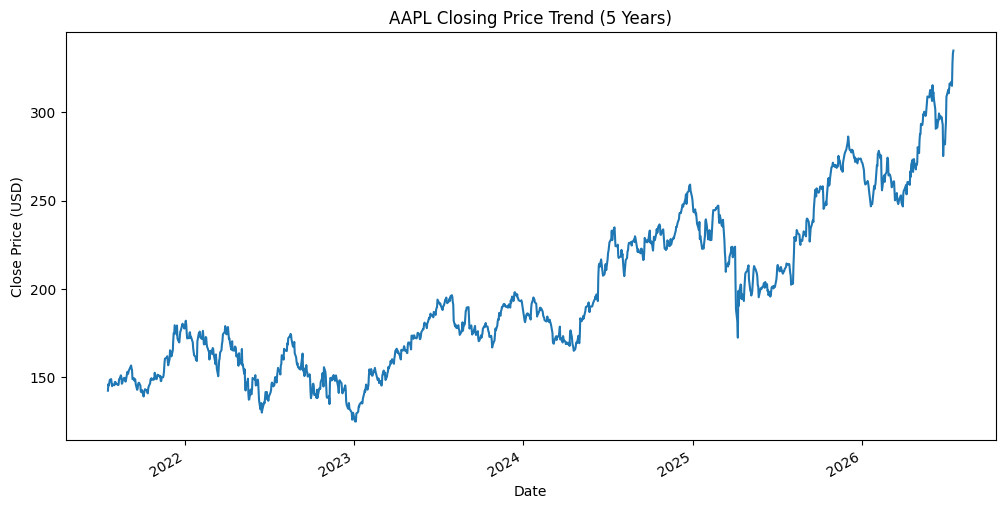

In [38]:
# Trend analysis — closing price across the full 5-year period
plt.figure(figsize=(12,6))
aapl['Close'].plot()
plt.title('AAPL Closing Price Trend (5 Years)')
plt.xlabel('Date')
plt.ylabel('Close Price (USD)')
plt.show()

C. Daily and Monthly Perofrmance Analysis

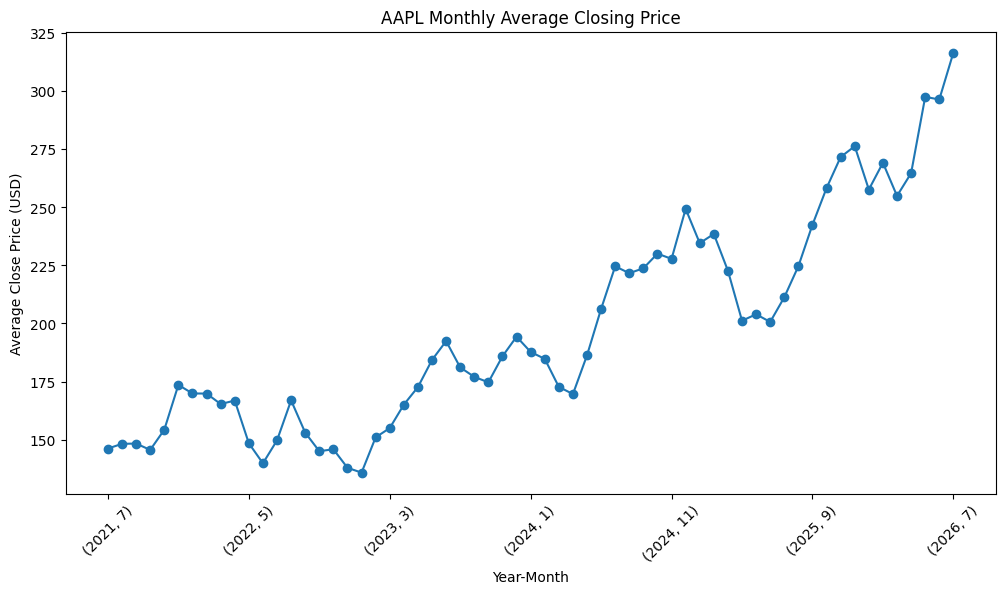

In [41]:
# Daily and monthly performance — average close price per year-month
plt.figure(figsize=(12,6))
monthly_avg_close.plot(kind='line', marker='o')
plt.title('AAPL Monthly Average Closing Price')
plt.xlabel('Year-Month')
plt.ylabel('Average Close Price (USD)')
plt.xticks(rotation=45)
plt.show()

Rolling Averages

<Figure size 1200x600 with 0 Axes>

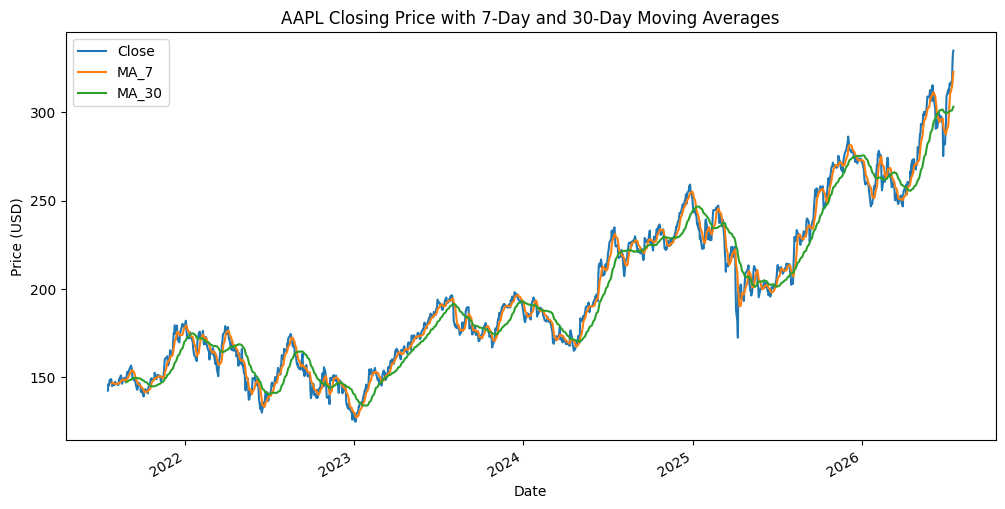

In [44]:
# Rolling averages (7-day and 30-day)
aapl['MA_7'] = aapl['Close'].rolling(window=7).mean()
aapl['MA_30'] = aapl['Close'].rolling(window=30).mean()

plt.figure(figsize=(12,6))
aapl[['Close', 'MA_7', 'MA_30']].plot(figsize=(12,6))
plt.title('AAPL Closing Price with 7-Day and 30-Day Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.show()

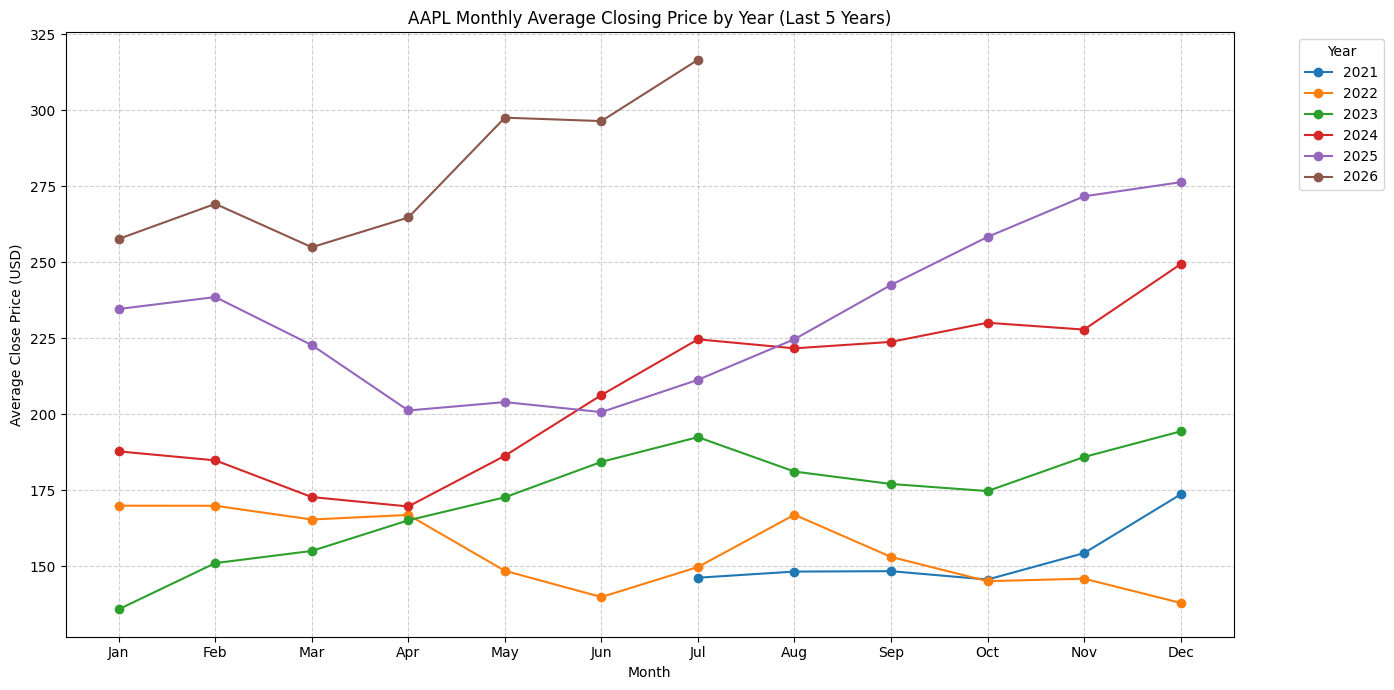

In [40]:
plt.figure(figsize=(14, 7))

# Unstack the 'Year' level to have years as columns and months as index
monthly_avg_close_by_year = monthly_avg_close.unstack(level='Year')

# Plotting each year as a separate line
monthly_avg_close_by_year.plot(ax=plt.gca(), marker='o', linestyle='-')

plt.title('AAPL Monthly Average Closing Price by Year (Last 5 Years)')
plt.xlabel('Month')
plt.ylabel('Average Close Price (USD)')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.legend(title='Year', bbox_to_anchor=(1.05, 1), loc='upper left') # Place legend outside the plot
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Percentage change analysis

,Pct_Change
Date,
2021-07-19,NaN
2021-07-20,2.597403
2021-07-21,-0.513171
2021-07-22,0.962861
2021-07-23,1.198910
...,...
2026-07-13,0.631105
2026-07-14,-0.772116
2026-07-15,4.014483


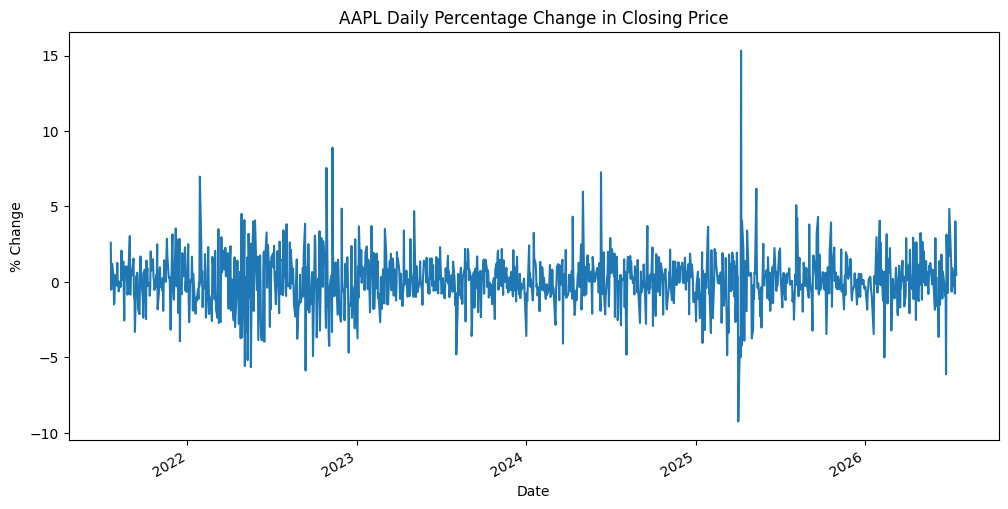

In [46]:

# Percentage change (day-over-day)
aapl['Pct_Change'] = aapl['Close'].pct_change() * 100
display(aapl['Pct_Change'])


# Visualization: Daily percentage change
plt.figure(figsize=(12,6))
aapl['Pct_Change'].plot()
plt.title('AAPL Daily Percentage Change in Closing Price')
plt.xlabel('Date')
plt.ylabel('% Change')
plt.show()

# 3. Feature Engineering Basics

A. Daily Price Change

In [ ]:
# Daily Price Change and Percentage Price Change has already been created above — Daily_Change, Pct_Change)

C. Moving Averages and Monthly returns

In [47]:

# Monthly Returns — % change in Close price from end of one month to the next
monthly_close = aapl['Close'].resample('ME').last()
monthly_returns = monthly_close.pct_change() * 100

## Printing out last 5 months
print("Monthly Returns (%):")
print(monthly_returns.tail())

Monthly Returns (%):
Date
2026-03-31    -3.932925
2026-04-30     6.919106
2026-05-31    15.002764
2026-06-30    -7.274242
2026-07-31    15.703622
Freq: ME, Name: Close, dtype: float64


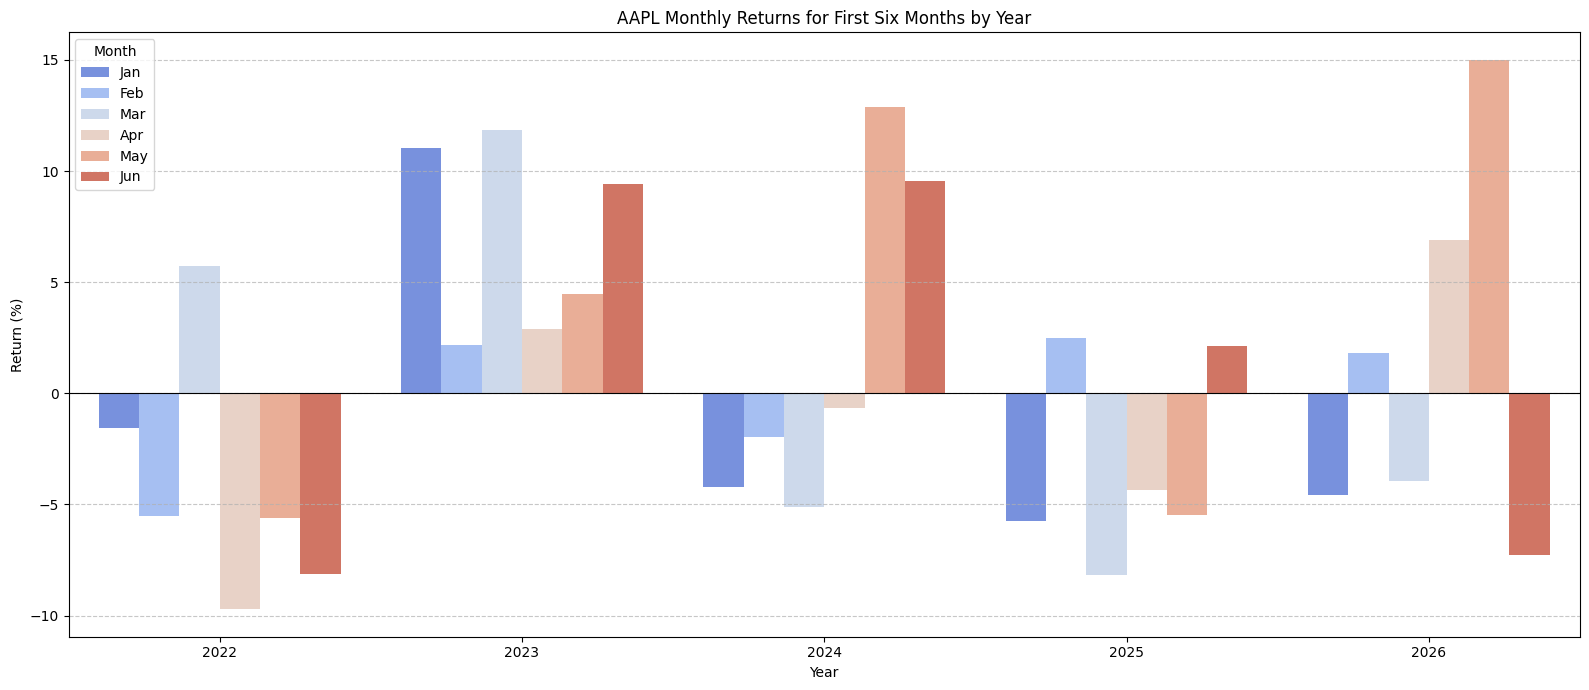

In [67]:
# Filter for the first five months (January to May) of each year
first_five_months_returns = monthly_returns_all[monthly_returns_all.index.month.isin([1, 2, 3, 4, 5, 6])]

# Prepare data for plotting
plot_data_first_five = first_five_months_returns.reset_index()
plot_data_first_five['Month_Name'] = plot_data_first_five['Date'].dt.strftime('%b')
plot_data_first_five['Year'] = plot_data_first_five['Date'].dt.year

plt.figure(figsize=(16, 7))
sns.barplot(x='Year', y='Close', hue='Month_Name', data=plot_data_first_five, palette='coolwarm')
plt.title('AAPL Monthly Returns for First Six Months by Year')
plt.xlabel('Year')
plt.ylabel('Return (%)')
plt.axhline(0, color='black', linewidth=0.8)
plt.xticks(rotation=0)
plt.legend(title='Month')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

D. Volatility Measures

In [50]:
# Volatility Measures — standard deviation of Close price
aapl['Volatility_7'] = aapl['Close'].rolling(window=7).std()
aapl['Volatility_30'] = aapl['Close'].rolling(window=30).std()

display(aapl[['Close', 'Volatility_7', 'Volatility_30']].tail())

,Close,Volatility_7,Volatility_30
Date,,,
2026-07-13,317.31,3.101434,11.367436
2026-07-14,314.86,2.267641,11.473666
2026-07-15,327.50,5.316421,12.428108
2026-07-16,333.26,7.582458,13.498506
2026-07-17,334.80,8.830973,14.691500


# Summary Table

In [52]:
# 1. Daily Price Change (already have this)
aapl['Daily_Change'] = aapl['Close'] - aapl['Open']

# 2. Percentage Price Change (already have this)
aapl['Pct_Change'] = aapl['Close'].pct_change() * 100

# 3. Moving Averages (already have this)
aapl['MA_7'] = aapl['Close'].rolling(window=7).mean()
aapl['MA_30'] = aapl['Close'].rolling(window=30).mean()

# 4. Monthly Returns — % change in Close price from end of one month to the next
monthly_close = aapl['Close'].resample('M').last()
monthly_returns = monthly_close.pct_change() * 100

# 5. Volatility Measures — rolling standard deviation of Close price
aapl['Volatility_7'] = aapl['Close'].rolling(window=7).std()
aapl['Volatility_30'] = aapl['Close'].rolling(window=30).std()

# 6. Additional feature — daily range as a % of opening price
aapl['Range_Pct'] = (aapl['Daily_Range'] / aapl['Open']) * 100

print("Monthly Returns:")
print(monthly_returns.tail())

print("\nFeature columns preview:")
display(aapl[['Close', 'Daily_Change', 'Pct_Change', 'MA_7', 'MA_30', 'Volatility_7', 'Volatility_30', 'Range_Pct']].tail())

Monthly Returns:
Date
2026-03-31    -3.932925
2026-04-30     6.919106
2026-05-31    15.002764
2026-06-30    -7.274242
2026-07-31    15.703622
Freq: ME, Name: Close, dtype: float64

Feature columns preview:


/tmp/ipykernel_692/952060012.py:12: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_close = aapl['Close'].resample('M').last()


,Close,Daily_Change,Pct_Change,MA_7,MA_30,Volatility_7,Volatility_30,Range_Pct
Date,,,,,,,,
2026-07-13,317.31,0.29,0.631105,313.455714,300.848000,3.101434,11.367436,2.419406
2026-07-14,314.86,1.10,-0.772116,314.345714,300.941333,2.267641,11.473666,1.364100
2026-07-15,327.50,9.88,4.014483,316.465714,301.647667,5.316421,12.428108,3.592343
2026-07-16,333.26,5.25,1.758779,319.694286,302.249667,7.582458,13.498506,2.405414
2026-07-17,334.80,2.82,0.462102,322.752857,303.067667,8.830973,14.691500,1.801313


## Key Findings and Conclusions

**1. Overall Trend:** Apple's closing price shows a general upward trajectory
across the 5-year period, consistent with the yearly average closing price
increasing year over year (see Yearly Summary table above).


**2. Volatility:** The 7-day and 30-day rolling volatility measures show that
Apple experiences periods of sharper price swings follwed by calmer
stretches, rather than constant volatility. The 30 day measure smooths out
short-term noise and highlights the broader risk pattern over time.

**3.Moving Averages:** The 7 day moving average tracks the daily closing price
closely, while the 30 day moving average lags behind and reacts more slowly.

**4.Trading Activity & Price Relationship:** Filtering the data revealed that
409 days had a below average opening price paired with above average trading
volume, compared to only 86 days where both closing price and volume were
above average. This suggests that lower opening prices may be associated
with increased buying activity.

**5. Monthly Returns:** Monthly returns fluctuate between positive and negative
values throughout the period, reflecting that Apple's stock, like most equities,
does not move in a straight line even while trending upward over the long run.

**Conclusion:** Over the 5-year period, AAPL shows a broadly positive trend
with recurring volatility, and trading volume appears more responsive to price
dips than to price highs.